Lab 4

In [1]:
import cv2
import time
import gymnasium as gym
from google.colab import output
from google.colab.patches import cv2_imshow
import numpy as np
mode = "rgb_array"
if mode == "Node":
    mode = None

(6, 3, 0)


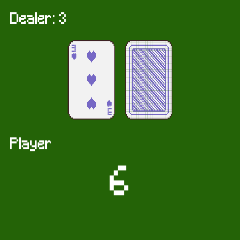

In [2]:
env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=mode)
observation, _ = env.reset()

print(f"{observation}")
img = env.render()
w, h, _ = img.shape
ratio = int(h / w)
new_w, new_h = (ratio * 240), 240
cv2_imshow(cv2.resize(img, (new_w, new_h))) #OpenCV

In [3]:
env.action_space, env.observation_space # Przestrzeń akcji i obseracje

(Discrete(2), Tuple(Discrete(32), Discrete(11), Discrete(2)))

In [4]:
from os import truncate
# 0 - pass
# 1 - dobierz kartę
observation, reward, terminated, truncated, info = env.step(1)

In [5]:
observation, reward, terminated, truncated # Jeśli jeden z parametrów true to koniec gry

((13, 3, 0), 0.0, False, False)

In [6]:
env.close()

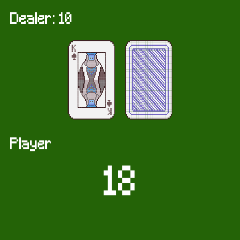

nagroda = -1.0, liczba punktów graczy = 18


In [7]:
def nowa_gra(env):
  observation, info = env.reset()
  img = env.render();
  w, h, _ = img.shape
  ratio = int(h / w)
  new_w, new_h = (ratio * 240), 240
  terminated = False
  truncated = False
  cv2_imshow(cv2.resize(img, (new_w, new_h)))
  time.sleep(0.1)

  if(observation[0] !=21):
    while (not terminated) and (not truncated):
      action = int(input('0 - pas, 1 - dobierz kartę\n'))
      observation, reward, terminated, truncated, info = env.step(action)
      output.clear(wait = True)
      time.sleep(0.1)

      img = env.render();
      cv2_imshow(cv2.resize(img, (new_w, new_h)))
      time.sleep(0.1)
  else:
    observation, reward, terminated, truncated, info = env.step(0)
  print(f"nagroda = {reward}, liczba punktów graczy = {observation[0]}")

env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=mode)
nowa_gra(env)
env.close()

Q-Learning
TO DO: sprawdz ile razy zwycięży skrypt przy losowaniu akcji

In [8]:
#Bez grafiki

def nowa_gra_sample(env):
  observation, info = env.reset()
  terminated = False
  truncated = False
  while (not terminated) and (not truncated):
    action = env.action_space.sample()
    print(f"{action}, obserwation, ", end='')
    observation, reward, terminated, truncated, info = env.step(action)
    print(f"{observation}, {reward}, {terminated}")
  print(f"nagroda = {reward}, liczba punktów gracza = {observation[0]}, liczba punktów przeciwnika = {observation[1]}")

env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=None)
nowa_gra_sample(env)
env.close()

1, obserwation, (11, 10, 0), 0.0, False
1, obserwation, (14, 10, 0), 0.0, False
1, obserwation, (24, 10, 0), -1.0, True
nagroda = -1.0, liczba punktów gracza = 24, liczba punktów przeciwnika = 10


Taxi

446


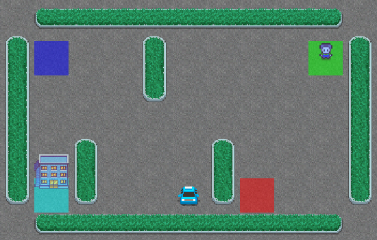

In [9]:
env = gym.make('Taxi-v4' , render_mode=mode) # rgb_array
#env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode='rgb_array') # rgb_array

#observation, info = env.reset()
observation, _ = env.reset()
print(f"{observation}")
img = env.render();
w, h, _ = img.shape
ratio = h/w                 # !!!
new_w, new_h = int(ratio* 240), 240 # !!!
cv2_imshow( cv2.resize(img, (new_w, new_h)) ) # OpenCV
#env.close()

In [10]:
env.action_space, env.observation_space

(Discrete(6), Discrete(500))

In [11]:
def flatten_state(env, obs):
    print(f"# [ info ] {obs}")
    if isinstance(obs, int):
        return obs
    else:
        ans = obs[0];
        prod = 1;
        for n in range(1, len(obs)):
            prod *= env.observation_space[n-1].n
            ans += prod*obs[n]
            #print(f"{prod*obs[n], prod}")
        return ans

observation, _ = env.reset()
flatten_state(env, observation)

# [ info ] 304


304

In [12]:
def nowa_gra_sample(env):
  observation, info = env.reset()
  terminated = False
  truncated = False
  while (not terminated) and (not truncated):
    # implementacja Q-learning --- do zrobienia
    action = env.action_space.sample() # losowo wybrana akcja # !!!!!!!!!!!!!!!!
    #print(f"{action}, {observation}, ", end='')
    observation, reward, terminated, truncated, info = env.step( action )
    #print(f"{observation}, {reward}, {terminated}")
  #print(f"nagroda = {reward}, liczba punktów gracza = {observation[0]}, liczba punktów przeciwnika = {observation[1]}")
  return reward
env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=None)

rewards = 0
draws = 0
for i in range(1000):
  tmp = round(nowa_gra_sample(env))
  if tmp > 0:
    rewards += 1
  elif tmp == 0:
    draws += 1
# rewards
print(f"{100*rewards / 1000.0}%, {rewards}, {draws}, {1000-(rewards+draws)}")


28.8%, 288, 42, 670


In [13]:
env.observation_space, 32*11*2, env.action_space.n

(Tuple(Discrete(32), Discrete(11), Discrete(2)), 704, np.int64(2))

In [23]:
def q_learning(env, episodes=1000, alpha=0.5, gamma=0.9, epsilon=0.8):
    # initialize Q_table
    prod = 1
    if isinstance(env.observation_space, gym.spaces.tuple.Tuple):
        for i in range(len(env.observation_space)):
            prod *= env.observation_space[i].n
    else:
        prod = env.observation_space.n

    Q_table = np.zeros([prod, env.action_space.n])
    step = 0
    rewards = []
    steps = []

    for episode in range(episodes):
        episode_reward = 0
        observation, info = env.reset()
        terminated = False
        truncated = False
        while (not terminated) and (not truncated):
            state = flatten_state(env, observation)
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q_table[state, :])

            observation, reward, terminated, truncated, info = env.step(action)
            next_state = flatten_state(env, observation)
            episode_reward += reward

            Q_table[state, action] = (1 - alpha) * Q_table[state, action] \
                + alpha * (reward + gamma * np.max(Q_table[next_state, :]))
            step += 1
            state = next_state


        rewards.append(episode_reward)
        steps.append(step)

        epsilon -= epsilon / episodes

        #Progress bar
        print(f"\r{100*episode//(episodes-1):>3}%|", end='')
        for j in range(10):
            if 10*episode//(episodes-1) % 11 > j:
                print("#", end='')
            else:
                print(" ", end='')
        print(f"| {episode:3}, {epsilon:.3f}, {episode_reward:5}, {step:5}", end='')

    return Q_table, rewards, steps

In [24]:
env = gym.make('Taxi-v4', render_mode=mode)
Q_table, rewards, steps = q_learning(env, episodes=1000)
env.close()

Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
# [ info ] 139
# [ info ] 239
# [ info ] 239
# [ info ] 259
# [ info ] 259
# [ info ] 279
# [ info ] 279
# [ info ] 259
# [ info ] 259
# [ info ] 279
# [ info ] 279
# [ info ] 379
# [ info ] 379
# [ info ] 479
# [ info ] 479
# [ info ] 475
 87%|########  | 872, 0.334,     5, 54423# [ info ] 2
# [ info ] 18
# [ info ] 18
# [ info ] 18
# [ info ] 18
# [ info ] 118
# [ info ] 118
# [ info ] 218
# [ info ] 218
# [ info ] 218
# [ info ] 218
# [ info ] 318
# [ info ] 318
# [ info ] 418
# [ info ] 418
# [ info ] 418
# [ info ] 418
# [ info ] 410
 87%|########  | 873, 0.334,     3, 54432# [ info ] 464
# [ info ] 364
# [ info ] 364
# [ info ] 384
# [ info ] 384
# [ info ] 284
# [ info ] 284
# [ info ] 184
# [ info ] 184
# [ info ] 84
# [ info ] 84
# [ info ] 96
# [ info ] 96
# [ info ] 196
# [ info ] 196
# [ info ] 96
# [ info ] 96
# [ info ] 196
# [ info ] 196
# [ info ] 176
# [ info ] 176
# [ info ] 276
# [ info ] 276
# [ info ]

In [15]:
print(*Q_table)

[0. 0. 0. 0. 0. 0.] [ -9.84182361  -9.84695814  -9.85039586  -9.84491778  -9.84447307
 -18.78161639] [ -9.89807787  -9.8948468   -9.89413001  -9.89360712  -9.89075194
 -18.868908  ] [ -9.85165936  -9.85441685  -9.85100027  -9.85394439  -9.85139858
 -18.81603319] [ -9.81352975  -9.8126882   -9.81187148  -9.8063297  -18.7608274
 -18.56747889] [0. 0. 0. 0. 0. 0.] [ -9.90933672  -9.91228306  -9.91508249  -9.91072557 -18.89508903
 -18.83230691] [ -9.87537022  -9.86741245  -9.86896978  -9.87360479 -18.84108471
 -18.84588101] [ -9.79247568  -9.79438036  -9.79842641  -9.79425125 -18.71460381
 -18.67714805] [ -9.88572767  -9.88282711  -9.88494238  -9.88259768 -18.83430423
 -18.75439506] [0. 0. 0. 0. 0. 0.] [ -9.87962327  -9.88037999  -9.87854237  -9.87810825 -18.8752175
 -18.82916503] [ -9.8100875   -9.80794857  -9.807477    -9.80510056 -18.73737277
 -18.78380663] [ -9.81261353  -9.80299221  -9.80534703  -9.80947092 -18.79638868
 -18.75464441] [ -9.89036341  -9.89295768  -9.89612546  -9.8917003

In [16]:
def nowa_gra_q_table(env):
  episode_rewards = 0 #jak black jack to zakomentuj to
  observation, info = env.reset()
  terminated = False
  truncated = False
  while (not terminated) and (not truncated):
    #action = env.action_space.sample()
    state = flatten_state(env, observation)
    action = np.argmax( Q_table[state, :] )
    observation, reward, terminated, truncated, info = env.step( action )
    episode_rewards += reward #jak black jack to zakomentuj to
  return reward
#env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=None)
env = gym.make('Taxi-v4' , render_mode=mode) # rgb_array

#Taxi
rewards = np.zeros((1000, 1))
for i in range(1000):
  rewards[i] = nowa_gra_q_table(env)

#Blackjack
#rewards = 0
#draws = 0
#for i in range(1000):
#  tmp = round(nowa_gra_q_table(env))
#  if tmp > 0:
#    rewards += 1
#  elif tmp == 0:
#    draws += 1



# rewards
#print(f"{rewards}, {100*rewards / 1000.0}%, {draws}, {1000-(rewards+draws)}")
print(f"{sum(rewards)/1000.0}, {max(rewards)}, {min(rewards)}") #to tez taxi

env.close()

Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ info ] 416
# [ info ] 316
# [ i